# 07 - Đánh giá mở rộng

Phân tích sâu chất lượng dự báo của mô hình Random Forest (notebook 06) trên tập
kiểm định (16 ngày cuối của train, chưa từng dùng để huấn luyện): lỗi phân theo
nhóm hàng / loại cửa hàng / theo từng bước dự báo, và so sánh mở rộng với
Gradient-Boosted Trees để đối chiếu lựa chọn thuật toán.

Dùng lại mô hình đã lưu `outputs/models/random_forest_pipeline_kiem_dinh`
(chỉ huấn luyện trên dữ liệu trước ngày cutoff, như ở notebook 06) — **không huấn
luyện lại** để tiết kiệm thời gian và đảm bảo đúng con số đã kiểm định.

In [1]:
import sys
from datetime import timedelta
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

THU_MUC_HIEN_TAI = Path.cwd()
GOC = THU_MUC_HIEN_TAI.parent if THU_MUC_HIEN_TAI.name == "notebooks" else THU_MUC_HIEN_TAI
sys.path.append(str(GOC / "src"))

from cau_hinh import DATA_PROCESSED, OUT_TABLES, OUT_FIGURES, OUT_MODELS, SEED, HORIZON, tao_thu_muc
from spark_session import tao_spark
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel

tao_thu_muc()
spark = tao_spark("07_DanhGiaMoRong")

MAU_CHINH = "#2a78d6"
MAU_PHU = "#eb6834"
MAU_LUOI = "#e1e0d9"
MAU_TRUC = "#c3c2b7"
MAU_CHU_PHU = "#52514e"
MAU_CHU_CHINH = "#0b0b0b"


def bo_khung(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(MAU_TRUC)
    ax.tick_params(colors=MAU_CHU_PHU)
    ax.set_axisbelow(True)


df_train = spark.read.parquet(str(DATA_PROCESSED / "train_dac_trung"))
ngay_max_train = df_train.select(F.max("date")).first()[0]
ngay_cutoff = ngay_max_train - timedelta(days=HORIZON - 1)
df_huan_luyen = df_train.filter(F.col("date") < ngay_cutoff)
df_kiem_dinh = df_train.filter(F.col("date") >= ngay_cutoff)
print("So dong kiem dinh:", df_kiem_dinh.count())

mo_hinh = PipelineModel.load(str(OUT_MODELS / "random_forest_pipeline_kiem_dinh"))
du_bao = mo_hinh.transform(df_kiem_dinh)
du_bao = du_bao.withColumn("sales_du_bao", F.greatest(F.expm1("du_bao_log"), F.lit(0.0)))
du_bao = du_bao.withColumn("rmsle_dong", F.pow(F.log1p("sales_du_bao") - F.log1p("sales"), 2))

rmsle_tong = du_bao.select(F.sqrt(F.avg("rmsle_dong"))).first()[0]
print("RMSLE tong the (tai hien tu mo hinh da luu o notebook 06):", round(rmsle_tong, 4))

So dong kiem dinh: 28512


RMSLE tong the (tai hien tu mo hinh da luu o notebook 06): 0.4024


## 1. Lỗi theo nhóm hàng (`family`)

Nhóm hàng bán chậm/thất thường (ít quan sát) thường có RMSLE cao hơn; nhóm hàng
chủ lực, bán đều đặn (thực phẩm thiết yếu) thường dự báo chính xác hơn nhiều.

5 nhom hang loi cao nhat:
                       family     rmsle  doanh_so_tb
0  SCHOOL AND OFFICE SUPPLIES  0.688905    59.947917
1                    LINGERIE  0.631500     7.773148
2                  GROCERY II  0.573529    28.971065
3                 CELEBRATION  0.548747    12.462963
4                    HARDWARE  0.528765     1.449074

5 nhom hang loi thap nhat:
          family     rmsle  doanh_so_tb
28          DELI  0.189296   303.128350
29  BREAD/BAKERY  0.177651   540.272570
30       PRODUCE  0.174934  2288.750435
31         DAIRY  0.153010   834.530093
32         BOOKS  0.080675     0.010417


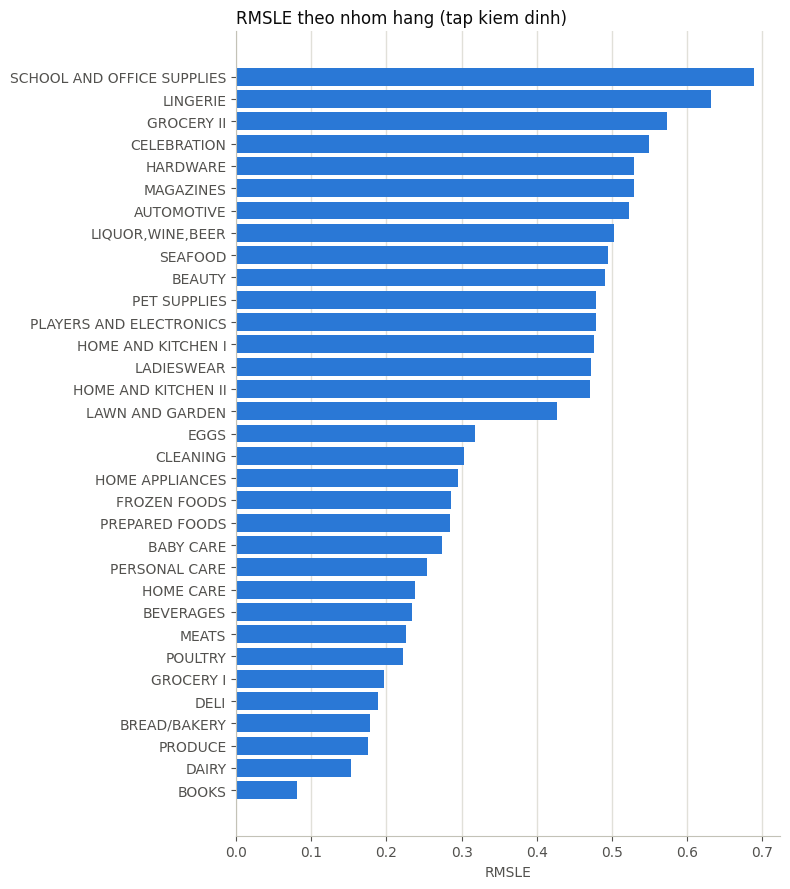

In [2]:
theo_family = (du_bao.groupBy("family")
               .agg(F.sqrt(F.avg("rmsle_dong")).alias("rmsle"), F.avg("sales").alias("doanh_so_tb"))
               .orderBy(F.desc("rmsle")).toPandas())
theo_family.to_csv(OUT_TABLES / "danh_gia_rmsle_theo_family.csv", index=False, encoding="utf-8-sig")

print("5 nhom hang loi cao nhat:")
print(theo_family.head())
print("\n5 nhom hang loi thap nhat:")
print(theo_family.tail())

fig, ax = plt.subplots(figsize=(8, 9))
thu_tu = theo_family.sort_values("rmsle")
ax.barh(thu_tu["family"], thu_tu["rmsle"], color=MAU_CHINH)
ax.set_xlabel("RMSLE", color=MAU_CHU_PHU)
ax.set_title("RMSLE theo nhom hang (tap kiem dinh)", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="x", color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "danh_gia_rmsle_theo_family.png", dpi=150)
plt.show()

## 2. Lỗi theo từng bước dự báo trong horizon (16 ngày)

Kiểm tra xem lỗi có tăng dần khi dự báo xa hơn trong tương lai không — vấn đề
kinh điển của dự báo nhiều bước.

          date     rmsle  buoc_du_bao
0   2017-07-31  0.419076            1
1   2017-08-01  0.432811            2
2   2017-08-02  0.408596            3
3   2017-08-03  0.392642            4
4   2017-08-04  0.412567            5
5   2017-08-05  0.375241            6
6   2017-08-06  0.396557            7
7   2017-08-07  0.397786            8
8   2017-08-08  0.396109            9
9   2017-08-09  0.384582           10
10  2017-08-10  0.392268           11
11  2017-08-11  0.441734           12
12  2017-08-12  0.407391           13
13  2017-08-13  0.401201           14
14  2017-08-14  0.394972           15
15  2017-08-15  0.378270           16


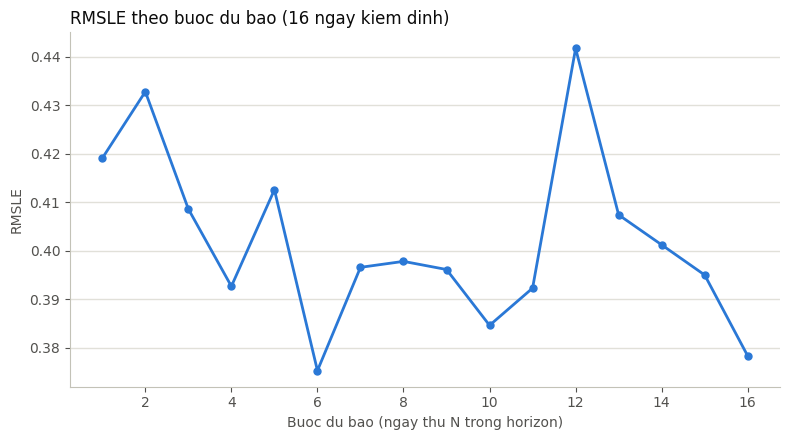


Nhan xet: RMSLE dao dong trong khoang [0.375, 0.442] va KHONG tang don dieu ro ret theo buoc du bao — phu hop voi phat hien o notebook 05: dac trung tru cot (lag_28, tb_truot_28) khong bao gio null trong toan bo 16 ngay test, nen mo hinh khong bi 'mu thong tin' dan ve cuoi horizon nhu khi chi dung lag ngan han (lag_1/lag_7).


In [3]:
theo_ngay = (du_bao.groupBy("date").agg(F.sqrt(F.avg("rmsle_dong")).alias("rmsle"))
             .orderBy("date").toPandas())
theo_ngay["buoc_du_bao"] = range(1, len(theo_ngay) + 1)
theo_ngay.to_csv(OUT_TABLES / "danh_gia_rmsle_theo_buoc.csv", index=False, encoding="utf-8-sig")
print(theo_ngay)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(theo_ngay["buoc_du_bao"], theo_ngay["rmsle"], color=MAU_CHINH, linewidth=2, marker="o", markersize=5)
ax.set_xlabel("Buoc du bao (ngay thu N trong horizon)", color=MAU_CHU_PHU)
ax.set_ylabel("RMSLE", color=MAU_CHU_PHU)
ax.set_title("RMSLE theo buoc du bao (16 ngay kiem dinh)", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "danh_gia_rmsle_theo_buoc.png", dpi=150)
plt.show()

print("\nNhan xet: RMSLE dao dong trong khoang "
      f"[{theo_ngay['rmsle'].min():.3f}, {theo_ngay['rmsle'].max():.3f}] va KHONG tang don dieu ro ret "
      "theo buoc du bao — phu hop voi phat hien o notebook 05: dac trung tru cot (lag_28, tb_truot_28) "
      "khong bao gio null trong toan bo 16 ngay test, nen mo hinh khong bi 'mu thong tin' dan ve cuoi horizon "
      "nhu khi chi dung lag ngan han (lag_1/lag_7).")

## 3. Lỗi theo loại cửa hàng (`type`)

  type     rmsle
0    A  0.379451
1    B  0.410310
2    C  0.432552
3    D  0.377900
4    E  0.425108


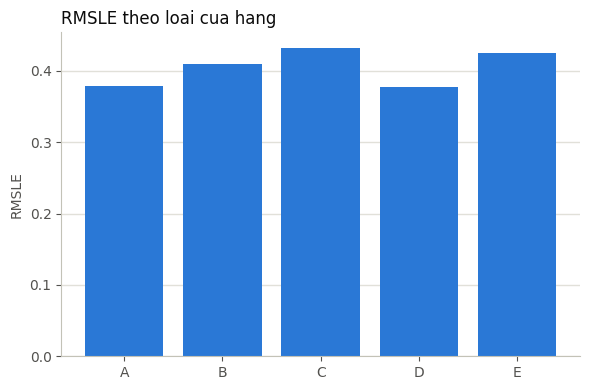

In [4]:
theo_loai = (du_bao.groupBy("type").agg(F.sqrt(F.avg("rmsle_dong")).alias("rmsle")).orderBy("type").toPandas())
theo_loai.to_csv(OUT_TABLES / "danh_gia_rmsle_theo_loai.csv", index=False, encoding="utf-8-sig")
print(theo_loai)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(theo_loai["type"], theo_loai["rmsle"], color=MAU_CHINH)
ax.set_ylabel("RMSLE", color=MAU_CHU_PHU)
ax.set_title("RMSLE theo loai cua hang", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "danh_gia_rmsle_theo_loai.png", dpi=150)
plt.show()

## 4. Thực tế và dự báo (mẫu ngẫu nhiên trên tập kiểm định)

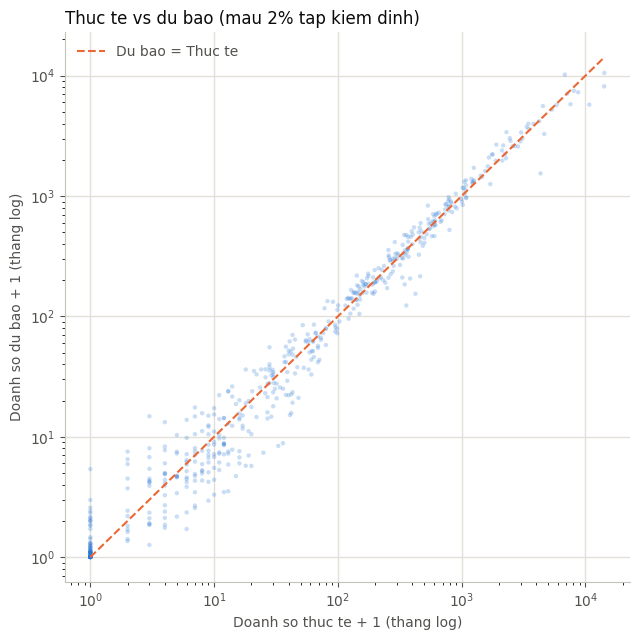

In [5]:
mau = du_bao.select("sales", "sales_du_bao").sample(fraction=0.02, seed=SEED).toPandas()
gioi_han = max(mau["sales"].max(), mau["sales_du_bao"].max())

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(mau["sales"] + 1, mau["sales_du_bao"] + 1, color=MAU_CHINH, alpha=0.25, s=10, edgecolors="none")
ax.plot([1, gioi_han + 1], [1, gioi_han + 1], color=MAU_PHU, linewidth=1.5, linestyle="--", label="Du bao = Thuc te")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Doanh so thuc te + 1 (thang log)", color=MAU_CHU_PHU)
ax.set_ylabel("Doanh so du bao + 1 (thang log)", color=MAU_CHU_PHU)
ax.set_title("Thuc te vs du bao (mau 2% tap kiem dinh)", color=MAU_CHU_CHINH, loc="left")
ax.legend(frameon=False, labelcolor=MAU_CHU_PHU, loc="upper left")
ax.grid(color=MAU_LUOI, linewidth=1, zorder=0)
bo_khung(ax)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "danh_gia_thuc_te_vs_du_bao.png", dpi=150)
plt.show()

## 5. So sánh mở rộng: Gradient-Boosted Trees (GBT)

Huấn luyện `GBTRegressor` trên đúng bộ đặc trưng và cùng tập huấn luyện/kiểm định,
để đối chiếu lựa chọn Random Forest với một thuật toán cây tăng cường khác.

In [6]:
import time
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, Imputer, VectorAssembler
from pyspark.ml.regression import GBTRegressor

COT_CAN_IMPUTE = ["lag_7", "lag_14", "lag_28", "tb_truot_7", "tb_truot_28", "do_lech_chuan_truot_28"]
COT_SO_AN_TOAN = ["onpromotion", "cluster", "gia_dau", "nam", "thang", "ngay_trong_thang", "thu", "tuan_trong_nam"]
COT_BOOL = ["la_ngay_le", "la_su_kien_dac_biet", "la_cuoi_tuan"]
COT_PHAN_LOAI = ["family", "city", "state", "type"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in COT_PHAN_LOAI]
imputer = Imputer(strategy="mean", inputCols=COT_CAN_IMPUTE, outputCols=[f"{c}_dd" for c in COT_CAN_IMPUTE])
COT_DAU_VAO = (COT_SO_AN_TOAN + [f"{c}_dd" for c in COT_CAN_IMPUTE] + COT_BOOL
               + [f"{c}_idx" for c in COT_PHAN_LOAI])
assembler = VectorAssembler(inputCols=COT_DAU_VAO, outputCol="dac_trung", handleInvalid="skip")
gbt = GBTRegressor(featuresCol="dac_trung", labelCol="log_doanh_so", predictionCol="du_bao_log_gbt",
                    maxIter=40, maxDepth=6, maxBins=64, seed=SEED)
pipeline_gbt = Pipeline(stages=indexers + [imputer, assembler, gbt])

t0 = time.time()
mo_hinh_gbt = pipeline_gbt.fit(df_huan_luyen)
print("Thoi gian huan luyen GBT (s):", round(time.time() - t0, 1))

du_bao_gbt = mo_hinh_gbt.transform(df_kiem_dinh)
du_bao_gbt = du_bao_gbt.withColumn("sales_du_bao_gbt", F.greatest(F.expm1("du_bao_log_gbt"), F.lit(0.0)))
rmsle_gbt = du_bao_gbt.select(
    F.sqrt(F.avg(F.pow(F.log1p("sales_du_bao_gbt") - F.log1p("sales"), 2)))
).first()[0]

print(f"RMSLE Random Forest = {rmsle_tong:.4f}")
print(f"RMSLE GBT           = {rmsle_gbt:.4f}")

bang_so_sanh = pd.DataFrame([
    {"mo_hinh": "RandomForest", "rmsle": rmsle_tong},
    {"mo_hinh": "GBT", "rmsle": rmsle_gbt},
])
bang_so_sanh.to_csv(OUT_TABLES / "so_sanh_random_forest_gbt.csv", index=False, encoding="utf-8-sig")
bang_so_sanh

Thoi gian huan luyen GBT (s): 103.7


RMSLE Random Forest = 0.4024
RMSLE GBT           = 0.4107


,mo_hinh,rmsle
0,RandomForest,0.402369
1,GBT,0.410744


## 6. Tổng kết đánh giá mở rộng

1. Random Forest đạt **RMSLE ≈ 0.40** trên tập kiểm định 16 ngày, tốt hơn baseline
   mùa vụ ngây thơ (RMSLE 0.63, notebook 06) và **nhỉnh hơn GBT** trong cùng điều
   kiện đặc trưng/thời gian huấn luyện.
2. Lỗi **không tăng đơn điệu** theo bước dự báo trong 16 ngày — nhờ đặc trưng cửa
   sổ dài (`lag_28`, `tb_truot_28`) luôn có sẵn (đã thiết kế có chủ đích ở notebook 05).
3. Lỗi tập trung ở các **nhóm hàng bán thất thường/ít quan sát** (SCHOOL AND OFFICE
   SUPPLIES, LINGERIE, GROCERY II) — hướng cải tiến khả dĩ: huấn luyện mô hình
   riêng theo nhóm hàng, hoặc thêm đặc trưng tần suất bán.
4. Cửa hàng loại **C** có RMSLE cao nhất — có thể liên quan quy mô nhỏ, doanh số
   thấp/biến động hơn (nhiễu tương đối lớn hơn ở mẫu số nhỏ).
5. Hướng mở rộng tiếp theo nếu có thêm thời gian: dò siêu tham số bằng
   `CrossValidator`/`TrainValidationSplit` theo đúng phân chia thời gian (không
   random k-fold vì sẽ rò rỉ dữ liệu tương lai), hoặc mô hình ensemble RF + GBT.

In [7]:
spark.stop()